---

# **<font color="#6767bf"> Modelación Climática Tropical</font>**
## **<font color="#8282d6"> Atlantic Multidecadal Variability </font>**
### **<font color="#a6a6f1"> Índices y mapas de anomalías MSWEP </font>**


---

In [1]:
pip install xarray

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install cftime

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install h5netcdf

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install netCDF4 

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install cartopy

Note: you may need to restart the kernel to use updated packages.


In [6]:
#Paqueterias
import pandas as pd
import xarray as xr
import numpy as np
import datetime
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature 
from cartopy.util import add_cyclic_point
from matplotlib import colors
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import pandas as pd
from scipy import stats
from scipy.stats import t

In [7]:
def lineplot_setup(xmin,xmax,xlab,ylab,ymin=None,ymax=None,title=None,legend=False):
    plt.xlim([xmin,xmax])
    plt.ylim([ymin,ymax])
    plt.grid(linestyle='--',alpha=0.66)
    plt.minorticks_on()
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlabel(xlab,fontsize=14)
    plt.ylabel(ylab,fontsize=14)
    plt.title(title,fontsize=14)
    if legend:
        plt.legend(fancybox=True,shadow=True,fontsize=9)

In [8]:
def mapa_MC(data, levels, ccmap, titulo, extend='both', cbarlabel='pr  [mm día$^{-1}$]', 
            limite_NS=75, lon_min=None, lon_max=None, lat_min=None, lat_max=None):
    lons, lats = data.lon, data.lat
    data, lon = add_cyclic_point(data, coord=lons)
    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.coastlines()
    cs = ax.contourf(lon, lats, data, levels=levels, cmap=ccmap, extend=extend, transform=ccrs.PlateCarree())

    if lon_min is not None and lon_max is not None and lat_min is not None and lat_max is not None:
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())
    else:
        ax.set_extent([0, 359.1, -limite_NS, limite_NS], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linestyle='--')
    ax.add_feature(cfeature.STATES.with_scale('10m'), edgecolor='k', linewidth=0.5)
    gl.top_labels = gl.right_labels = False
    gl.xlabel_style = {'size': 13}
    gl.ylabel_style = {'size': 13}
    plt.title(titulo, fontsize=19)
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1)
    cbar = plt.colorbar(cs, orientation='horizontal', fraction=0.046, pad=0.06)
    cbar.ax.set_xlabel(cbarlabel)

In [9]:
# Cargamos el archivo del índice AMV de la NOAA ERSSTv5
file_path = 'AMV_NOAA_df.csv'
df = pd.read_csv(file_path)

df['Date'] = pd.to_datetime(df['Date'])  

In [10]:
# Imprimimos los valores positivos
#positivos = amv_JJAS[amv_JJAS['AMV_NOAA'] > 0]
#positivos

In [11]:
df['rolled']=df.AMV_NOAA.rolling(window=120, min_periods=60).mean()

In [12]:
# se filtran los meses de JJAS con dt month que extrae el mes y con isin se especifican las filas
amv_JJAS = df[df['Date'].dt.month.isin([6, 7, 8, 9])]
print(amv_JJAS)

           Date  AMV_NOAA    rolled
5    1854-06-15     -0.18       NaN
6    1854-07-15     -0.07       NaN
7    1854-08-15     -0.20       NaN
8    1854-09-15     -0.04       NaN
17   1855-06-15     -0.06       NaN
...         ...       ...       ...
2024 2022-09-15      0.98  0.592750
2033 2023-06-15      1.27  0.624000
2034 2023-07-15      1.44  0.631583
2035 2023-08-15      1.36  0.638750
2036 2023-09-15      1.42  0.645500

[680 rows x 3 columns]


In [13]:
# Imprimimos los valores negativos
negativos = amv_JJAS[amv_JJAS['AMV_NOAA'] < 0]
negativos

,Date,AMV_NOAA,rolled
5,1854-06-15,-0.18,NaN
6,1854-07-15,-0.07,NaN
7,1854-08-15,-0.20,NaN
8,1854-09-15,-0.04,NaN
17,1855-06-15,-0.06,NaN
...,...,...,...
1687,1994-08-15,-0.22,-0.046417
1688,1994-09-15,-0.18,-0.047083
1709,1996-06-15,-0.03,0.023917
1710,1996-07-15,-0.08,0.024833


In [14]:
# Debemos cargar los archivos, tanto el csv como el .nc con la variable

# Archivo de precipitación MSWEP
filename='/home/jovyan/ModClim/datos_actualizados/MSWEP_monthly_1980-2023.nc'
ds=xr.open_dataset(filename)
pr=ds['precipitation']
pr=pr*8
pr['units']='mm day-1'
pr

<xarray.DataArray 'precipitation' (time: 528, lat: 180, lon: 576)> Size: 219MB
array([[[2.562693  , 2.6024406 , 2.7338846 , ..., 3.0799243 ,
         2.9871328 , 2.7391763 ],
        [2.351883  , 2.2910767 , 2.353475  , ..., 2.979433  ,
         2.9485087 , 2.6356468 ],
        [2.237777  , 2.0963643 , 2.2239435 , ..., 2.6712742 ,
         2.6104686 , 2.431325  ],
        ...,
        [3.4713626 , 3.209657  , 2.7960432 , ..., 4.2770653 ,
         4.119744  , 3.8807352 ],
        [3.8979201 , 3.5536423 , 3.0383923 , ..., 3.6893911 ,
         3.9565306 , 4.1928635 ],
        [4.4706793 , 4.0528026 , 3.6469212 , ..., 3.503539  ,
         4.4710317 , 4.7945833 ]],

       [[2.6609406 , 2.4711268 , 2.282222  , ..., 2.4305298 ,
         2.5218227 , 2.5943134 ],
        [2.170432  , 2.0174098 , 2.0280635 , ..., 2.2015262 ,
         2.4642882 , 2.3559856 ],
        [1.7563738 , 1.5585538 , 1.672821  , ..., 2.0591736 ,
         2.278307  , 2.0179796 ],
...
        [6.012203  , 4.334403  , 3.551765  , ..., 8.868039  ,
         7.4874964 , 6.70755   ],
        [6.1414185 , 5.2041698 , 4.2199287 , ..., 8.020544  ,
         7.806594  , 6.697964  ],
        [6.0353856 , 5.469911  , 4.7717686 , ..., 8.155971  ,
         7.6964846 , 6.613976  ]],

       [[2.6519916 , 2.5411613 , 2.3672307 , ..., 2.0777428 ,
         2.0828552 , 2.3997886 ],
        [2.376737  , 2.5435457 , 2.3775585 , ..., 2.0550432 ,
         2.0518403 , 2.2449942 ],
        [2.2503383 , 2.2808568 , 2.401311  , ..., 2.0249834 ,
         1.9847343 , 2.0436695 ],
        ...,
        [3.1784782 , 2.5007682 , 1.8772199 , ..., 4.5417237 ,
         3.8065064 , 3.4520288 ],
        [2.9520423 , 2.6906555 , 2.417251  , ..., 3.8678842 ,
         3.3487303 , 2.737187  ],
        [3.470249  , 3.3645365 , 3.0199528 , ..., 4.3574333 ,
         3.7158394 , 3.123335  ]]], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1980-01-16T09:00:00 ... 2023-12-16T09:...
  * lat      (lat) float64 1kB -44.75 -44.25 -43.75 -43.25 ... 43.75 44.25 44.75
  * lon      (lon) float64 5kB 0.3125 0.9375 1.562 2.188 ... 358.4 359.1 359.7
    units    <U8 32B 'mm day-1'

In [15]:
lons=pr.lon
lats=pr.lat
#pr=pr.loc[dict(lat=lats[lats>0])]
#pr=pr.loc[dict(lon=lons[lons>180])]

In [16]:
df_csv=df

In [17]:
# Tenemos que obtener el promedio de los años con AMO
pr_jjas=pr.sel(time=pr['time'].dt.month.isin([6, 7, 8, 9]))
print(pr_jjas)

<xarray.DataArray 'precipitation' (time: 176, lat: 180, lon: 576)> Size: 73MB
array([[[3.6968997 , 4.1765714 , 4.605028  , ..., 3.5025904 ,
         3.4209785 , 3.397676  ],
        [3.9489748 , 4.449613  , 4.7988253 , ..., 3.537124  ,
         3.5966697 , 3.7570875 ],
        [3.9443133 , 4.009031  , 3.9166324 , ..., 3.5902703 ,
         3.7956212 , 3.9107604 ],
        ...,
        [2.0870543 , 2.1597166 , 1.6634128 , ..., 3.0382166 ,
         2.8960488 , 2.5011177 ],
        [1.9832969 , 1.9435625 , 1.9943974 , ..., 2.4642196 ,
         2.7560132 , 2.5804765 ],
        [2.7238367 , 2.990742  , 2.5590405 , ..., 2.4550345 ,
         2.8810399 , 2.8781438 ]],

       [[3.192906  , 3.1687064 , 3.1652873 , ..., 3.9289346 ,
         3.5831876 , 3.3547313 ],
        [3.4355335 , 3.3302884 , 3.172368  , ..., 3.8837717 ,
         3.5579538 , 3.4792366 ],
        [3.6409674 , 3.4805732 , 3.4811347 , ..., 3.7061436 ,
         3.6247895 , 3.7312582 ],
...
        [0.987276  , 1.0487883 , 0.9775

In [18]:
# Seleccionamos el área especifica
time_yrsprep=pr_jjas.sel(time=slice('1980', '2023'))
pr_jjas_centromex = time_yrsprep.sel(lat=slice(13.75, 23.75),lon=slice(253.75, 273.5))
#pr_jjas_centromex=pr_jjas_centromex.mean()
pr_jjas_prom_centromex = pr_jjas_centromex.mean(dim=["lat", "lon"]) #skipna=True

pr_jjas_prom_centromex_anual=pr_jjas_prom_centromex.groupby('time.year').mean('time')

pr_jjas_prom_centromex_anual

<xarray.DataArray 'precipitation' (year: 44)> Size: 176B
array([6.7041507, 8.004066 , 5.2073946, 6.8720713, 8.514896 , 5.9753156,
       5.0708485, 6.3713374, 8.159102 , 6.8498087, 6.2972326, 5.916814 ,
       6.123365 , 7.7610517, 4.8926134, 7.5718   , 6.600377 , 5.4421597,
       7.146392 , 7.904214 , 6.4027815, 5.769167 , 6.3618555, 6.3959246,
       5.572566 , 6.7612453, 6.126119 , 6.2027206, 7.657843 , 5.3252497,
       8.679527 , 7.2718987, 6.1725   , 7.5918074, 6.401348 , 4.8920527,
       5.893242 , 6.717329 , 5.106411 , 4.733793 , 6.0027914, 6.663768 ,
       6.4003987, 4.4412956], dtype=float32)
Coordinates:
  * year     (year) int64 352B 1980 1981 1982 1983 1984 ... 2020 2021 2022 2023
    units    <U8 32B 'mm day-1'

In [19]:
years_amv = [1980,1981,1982,1983,1984,1985,1986,1987,1988,1989,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023]
df_filtrado = amv_JJAS[amv_JJAS['Date'].dt.year.isin(years_amv)]


df_filtrado['year'] = df_filtrado['Date'].dt.year
promedios_amv = df_filtrado.groupby('year')['rolled'].mean()
print(promedios_amv)

year
1980   -0.192188
1981   -0.161354
1982   -0.129979
1983   -0.112063
1984   -0.081875
1985   -0.072854
1986   -0.066812
1987   -0.048917
1988   -0.020458
1989   -0.010500
1990   -0.014063
1991   -0.012167
1992   -0.019396
1993   -0.032771
1994   -0.046271
1995   -0.006750
1996    0.027021
1997    0.035417
1998    0.054896
1999    0.087729
2000    0.105687
2001    0.122021
2002    0.165187
2003    0.210521
2004    0.272167
2005    0.305729
2006    0.347208
2007    0.386250
2008    0.394813
2009    0.384542
2010    0.418104
2011    0.444854
2012    0.455771
2013    0.479417
2014    0.473896
2015    0.465688
2016    0.476500
2017    0.499437
2018    0.512229
2019    0.533187
2020    0.548063
2021    0.563438
2022    0.591313
2023    0.634958
Name: rolled, dtype: float64


/tmp/ipykernel_922/3783410769.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtrado['year'] = df_filtrado['Date'].dt.year


In [20]:
print(len(promedios_amv), len(pr_jjas_prom_centromex_anual))  # Deberían ser iguales

44 44


In [21]:
x = promedios_amv.values.astype(float)
y = pr_jjas_prom_centromex_anual.values.astype(float)

In [22]:
years = np.arange(1980, 2024)

In [23]:
X2=x
#np.save('promediosAMV_MSWEP_modelo.npy',X2)
y2=y
#np.save('promediosprecip_MSWEP_modelo.npy',y2)

In [24]:
# Coeficientes
m2 = np.sum((X2 - X2.mean()) * (y2 - y2.mean())) / np.sum((X2 - X2.mean())**2)
b2 = y2.mean() - m2 * X2.mean()
#predicciones2= b2 + m2 * years
predicciones2 = m2 * X2 + b2      #predicciones 
#np.save('predicciones_MSWEP_modelo.npy',predicciones2)
b2

np.float64(6.615370521777391)

In [25]:
residual = y2 - predicciones2
#np.save('residual_MSWEP_AMV.npy',residual)
# Calcular pendiente
m4 = np.sum((years - np.mean(years)) * (residual - np.mean(residual))) / np.sum((years - np.mean(years))**2)
b4 =  np.mean(residual) - m4 * np.mean(years)
predicciones= b4 + m4 * years
#np.save('predicciones_MSWEP_AMV.npy',predicciones)
m4_siglo=m4*100
#np.save('pendiente_MSWEP_sinAMV.npy',m4_siglo)
m4_siglo

np.float64(-0.3017651696262553)

In [26]:
from statistics import correlation

r=correlation(X2, y2)

r
#np.save('correlacion_MSWEP.npy',r)

-0.22301921501321173

In [27]:
from scipy import stats

correlacion_spearman, p_value = stats.spearmanr(X2, y2)

print(f"correlación de Spearman en GPCP: {correlacion_spearman}")
print(f"valor p: {p_value}")

correlación de Spearman en GPCP: -0.20098661028893586
valor p: 0.1908020796996406


In [28]:
from scipy.stats import pearsonr

r, p_value = pearsonr(X2, y2)
print("Coeficiente de correlación de Pearson:", r)
print("Valor p:", p_value)

Coeficiente de correlación de Pearson: -0.2230192150132118
Valor p: 0.1456268105883121


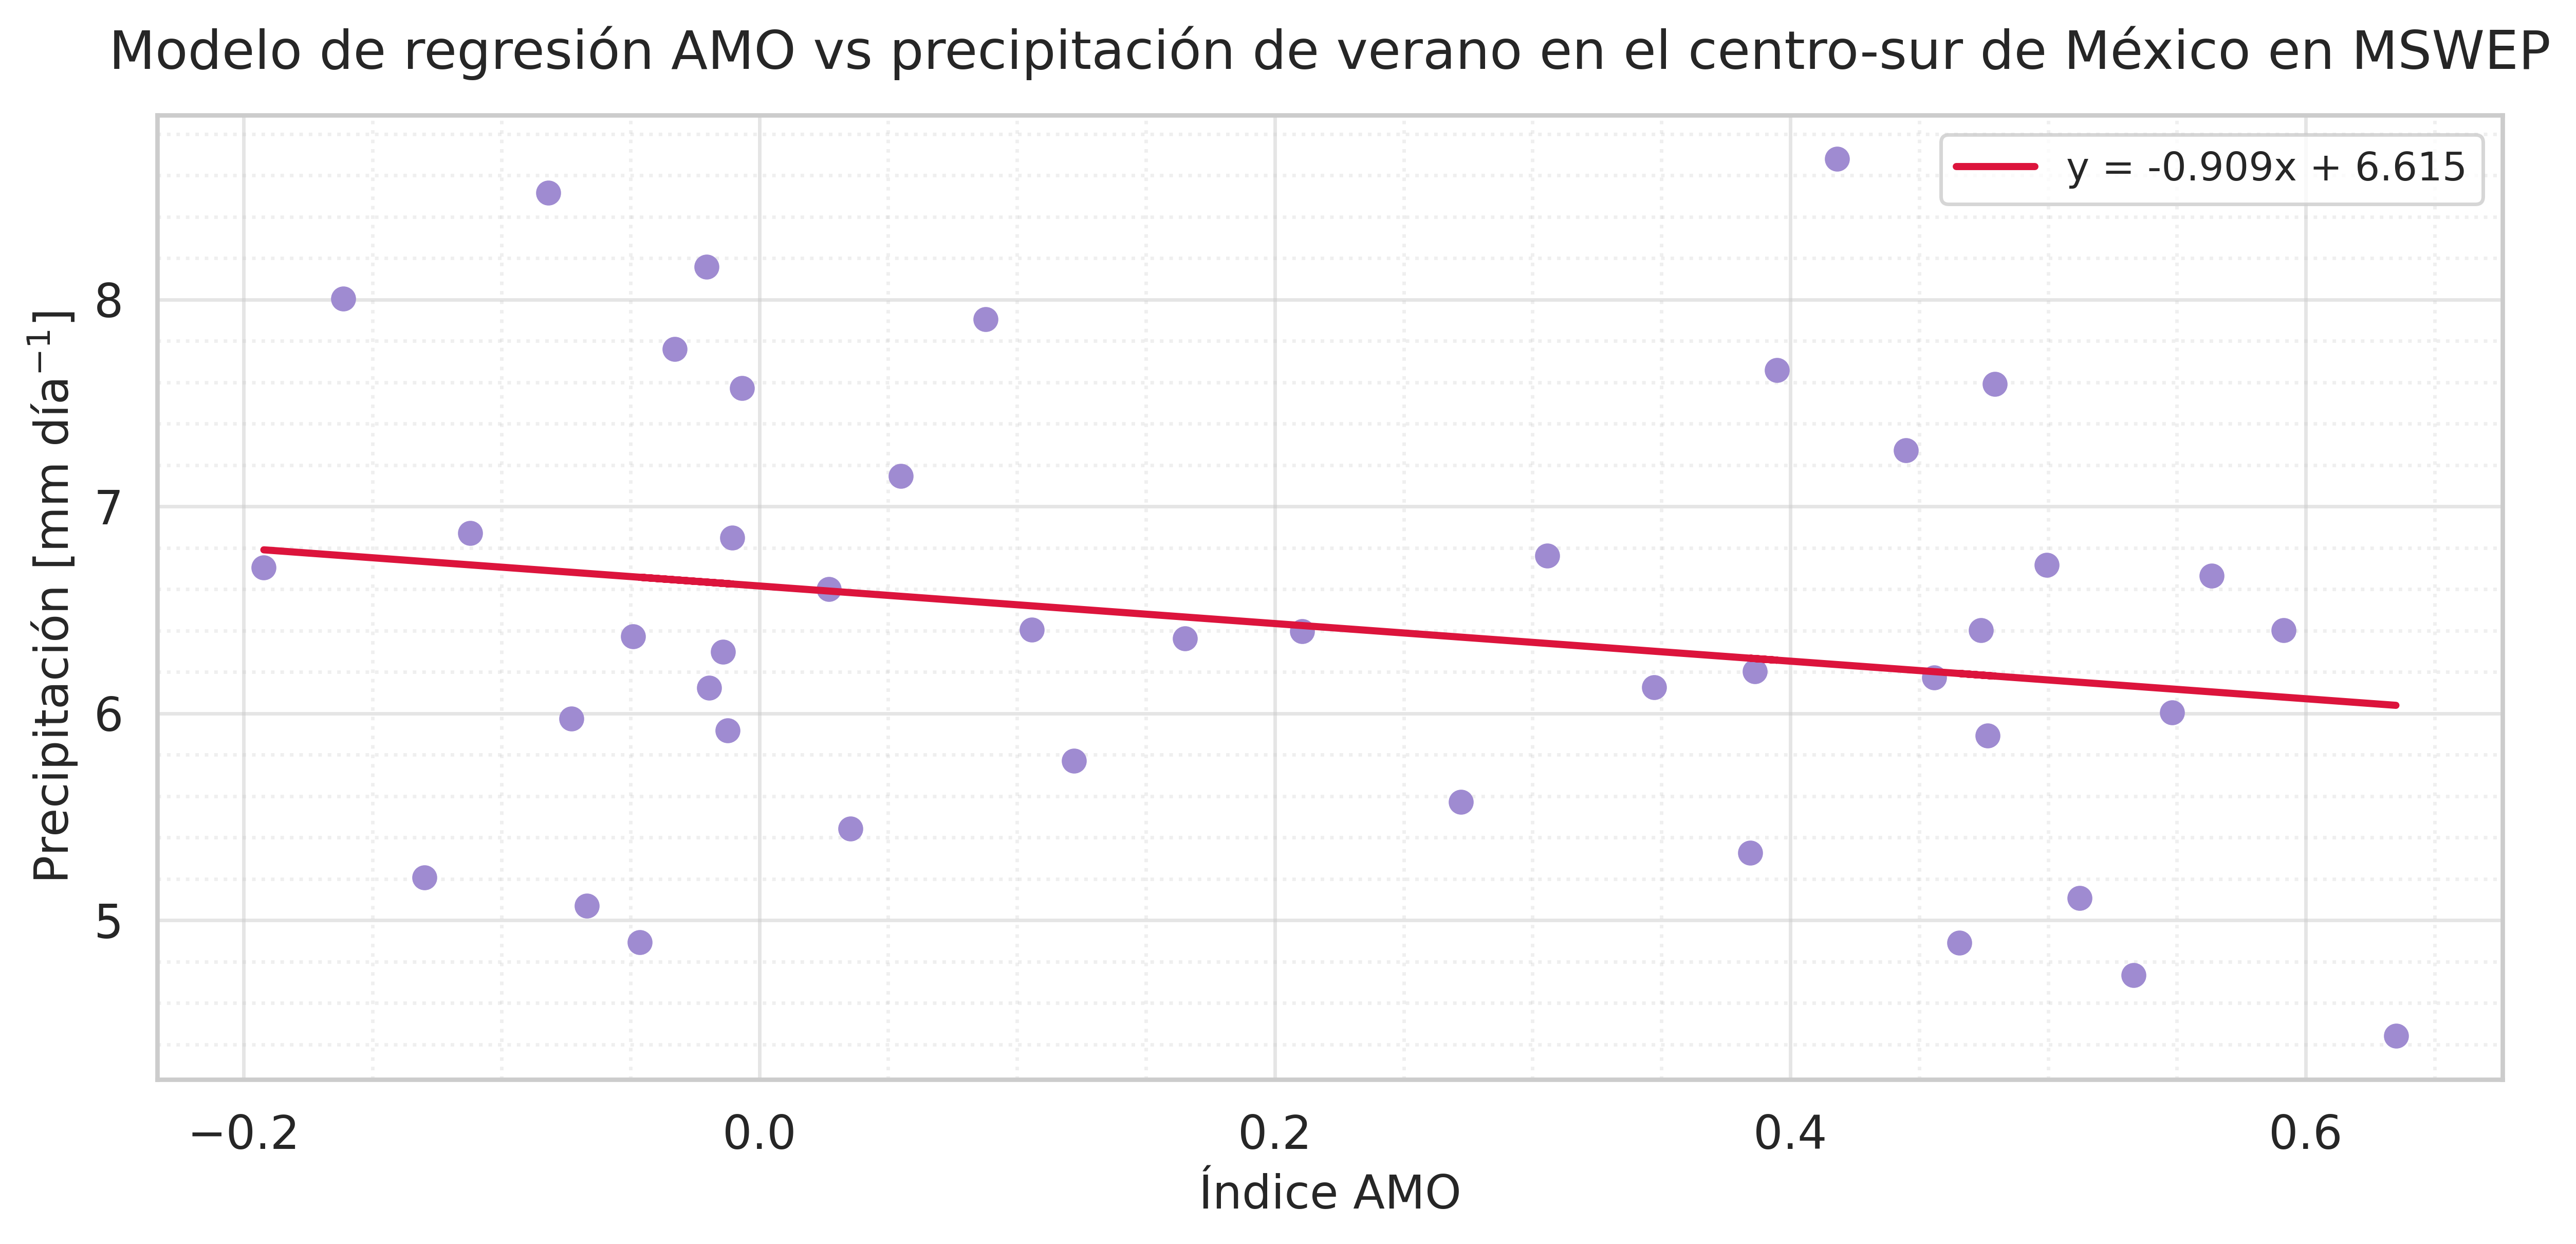

In [29]:
from matplotlib.ticker import MultipleLocator

sns.set(style="whitegrid")
plt.figure(figsize=(10, 5), dpi=500)
plt.scatter(X2, y, color='#9f8bd1')
plt.plot(X2, predicciones2, color='crimson', linewidth=2, label=f'y = {m2:.3f}x + {b2:.3f}')
plt.xlabel('Índice AMO', fontsize=13)
plt.ylabel('Precipitación [mm día$^{-1}$]', fontsize=13)
plt.title('Modelo de regresión AMO vs precipitación de verano en el centro-sur de México en MSWEP',fontsize=15 ,pad=13, x=0.5)
plt.grid(True, which='major', linestyle='-', alpha=0.5)  
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', alpha=0.3)  
plt.yticks(fontsize=13)
plt.xticks(fontsize=13)
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
res = stats.linregress(X2, y)
#np.save('predicciones_mswep.npy', predicciones2)
print(res)

LinregressResult(slope=np.float64(-0.9085635126980308), intercept=np.float64(6.615370521777391), rvalue=np.float64(-0.22301921501321187), pvalue=np.float64(0.1456268105883119), stderr=np.float64(0.6127878465405878), intercept_stderr=np.float64(0.19840965648936032))


In [31]:
df = len(X2) - 2
t_obs = res.slope / res.stderr
t_crit = t.ppf(1 - 0.05/2, df)

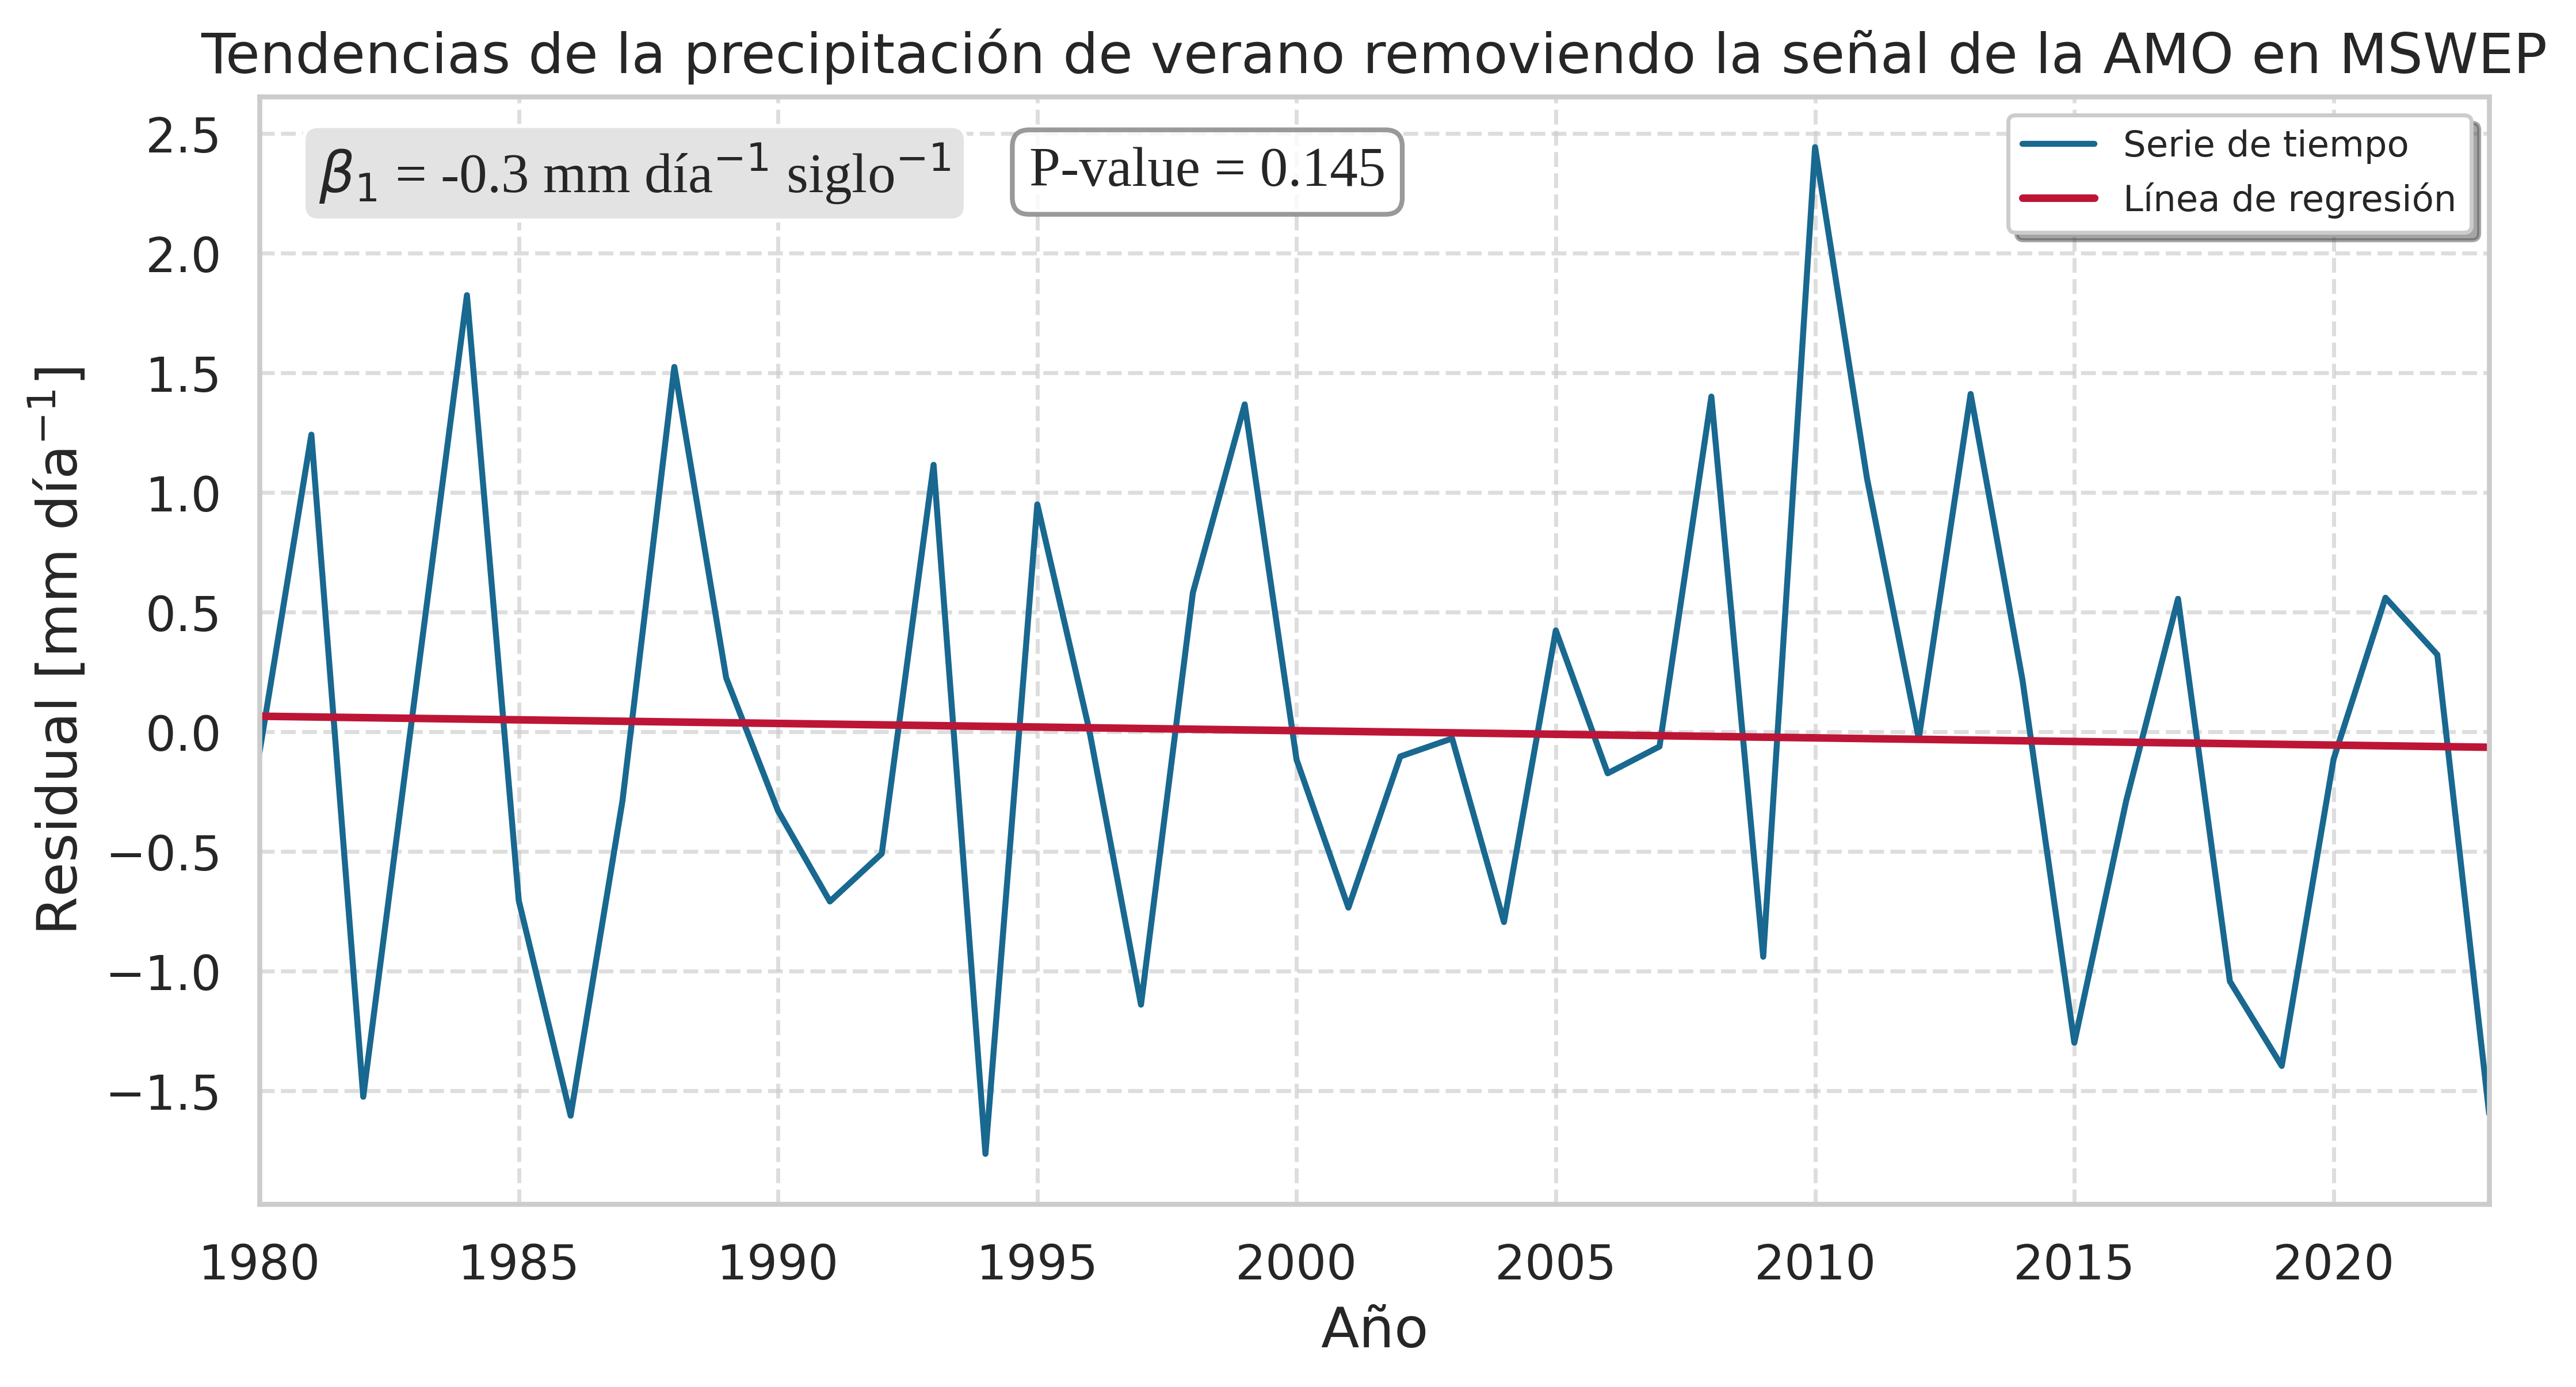

In [32]:
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker

plt.figure(figsize=(10,5), dpi=500)
plt.plot(years, residual, color='#186890', label='Serie de tiempo', linewidth=1.5)
plt.plot(years, predicciones, color='#bd1536', label='Línea de regresión',linewidth=1.9)
#plt.text(0.05, 0.95, 'b)', transform=plt.gca().transAxes, fontsize=17, fontname='Liberation Serif', fontweight='bold', va='top', ha='right',
 #       bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.27', linewidth=1))
lineplot_setup(1980,2023,'Año','Residual [mm día$^{-1}$]',title='Tendencias de la precipitación de verano removiendo la señal de la AMO en MSWEP',legend=True)

plt.text(0.31, 0.96, r'$\beta_1$ = -0.3 mm día$^{-1}$ siglo$^{-1}$', transform=plt.gca().transAxes, fontsize=14, fontname='Liberation Serif', fontweight='normal', va='top', ha='right',
        bbox=dict(facecolor='#E3E3E3', edgecolor='white', boxstyle='round,pad=0.27', linewidth=1))

plt.text(0.505, 0.955,rf'P-value = 0.145',transform=plt.gca().transAxes,fontsize=14,fontname='Liberation Serif',fontweight='normal',va='top', ha='right',
        bbox=dict(facecolor='white', edgecolor='gray',boxstyle='round,pad=0.3',alpha=0.8,linewidth=1.2))

ax = plt.gca()  
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))  

In [33]:
pendiente, intercepto, r_value, pval, stderr = stats.linregress(years, residual)

print("pendiente:", pendiente)
print("p-valor:", pval)
if pval < 0.05:
    print("estadísticamente significativa al 95% de confianza")
else:
    print("No es significativa al 95%")

pendiente: -0.003017651696262552
p-valor: 0.8047771504036184
No es significativa al 95%


In [34]:
correlacion_gpcc=np.load('correlacion_GPCC.npy')
correlacion_gpcp=np.load('correlacion_GPCP.npy')
correlacion_mswep=np.load('correlacion_MSWEP.npy')

In [35]:
correlaciones = []
for i in range(1, 31):
    file = f'correlacion_0{i}_SPEAR_.npy'
    data = np.load(file)
    correlaciones.append(data)

In [36]:
correlaciones

[array(-0.00964253),
 array(-0.04774837),
 array(0.14211415),
 array(0.2502504),
 array(0.02098006),
 array(-0.03284486),
 array(-0.07150591),
 array(-0.05685432),
 array(-0.08127391),
 array(-0.00592755),
 array(0.05252429),
 array(-0.02735083),
 array(0.0417269),
 array(0.08043397),
 array(0.17586479),
 array(-0.04935321),
 array(0.18365621),
 array(0.11365649),
 array(0.08939365),
 array(-0.22573234),
 array(0.07696683),
 array(0.0852567),
 array(-0.08857361),
 array(0.09908793),
 array(0.0218078),
 array(0.10996134),
 array(-0.15019812),
 array(-0.02748141),
 array(-0.00298174),
 array(-0.00592737)]

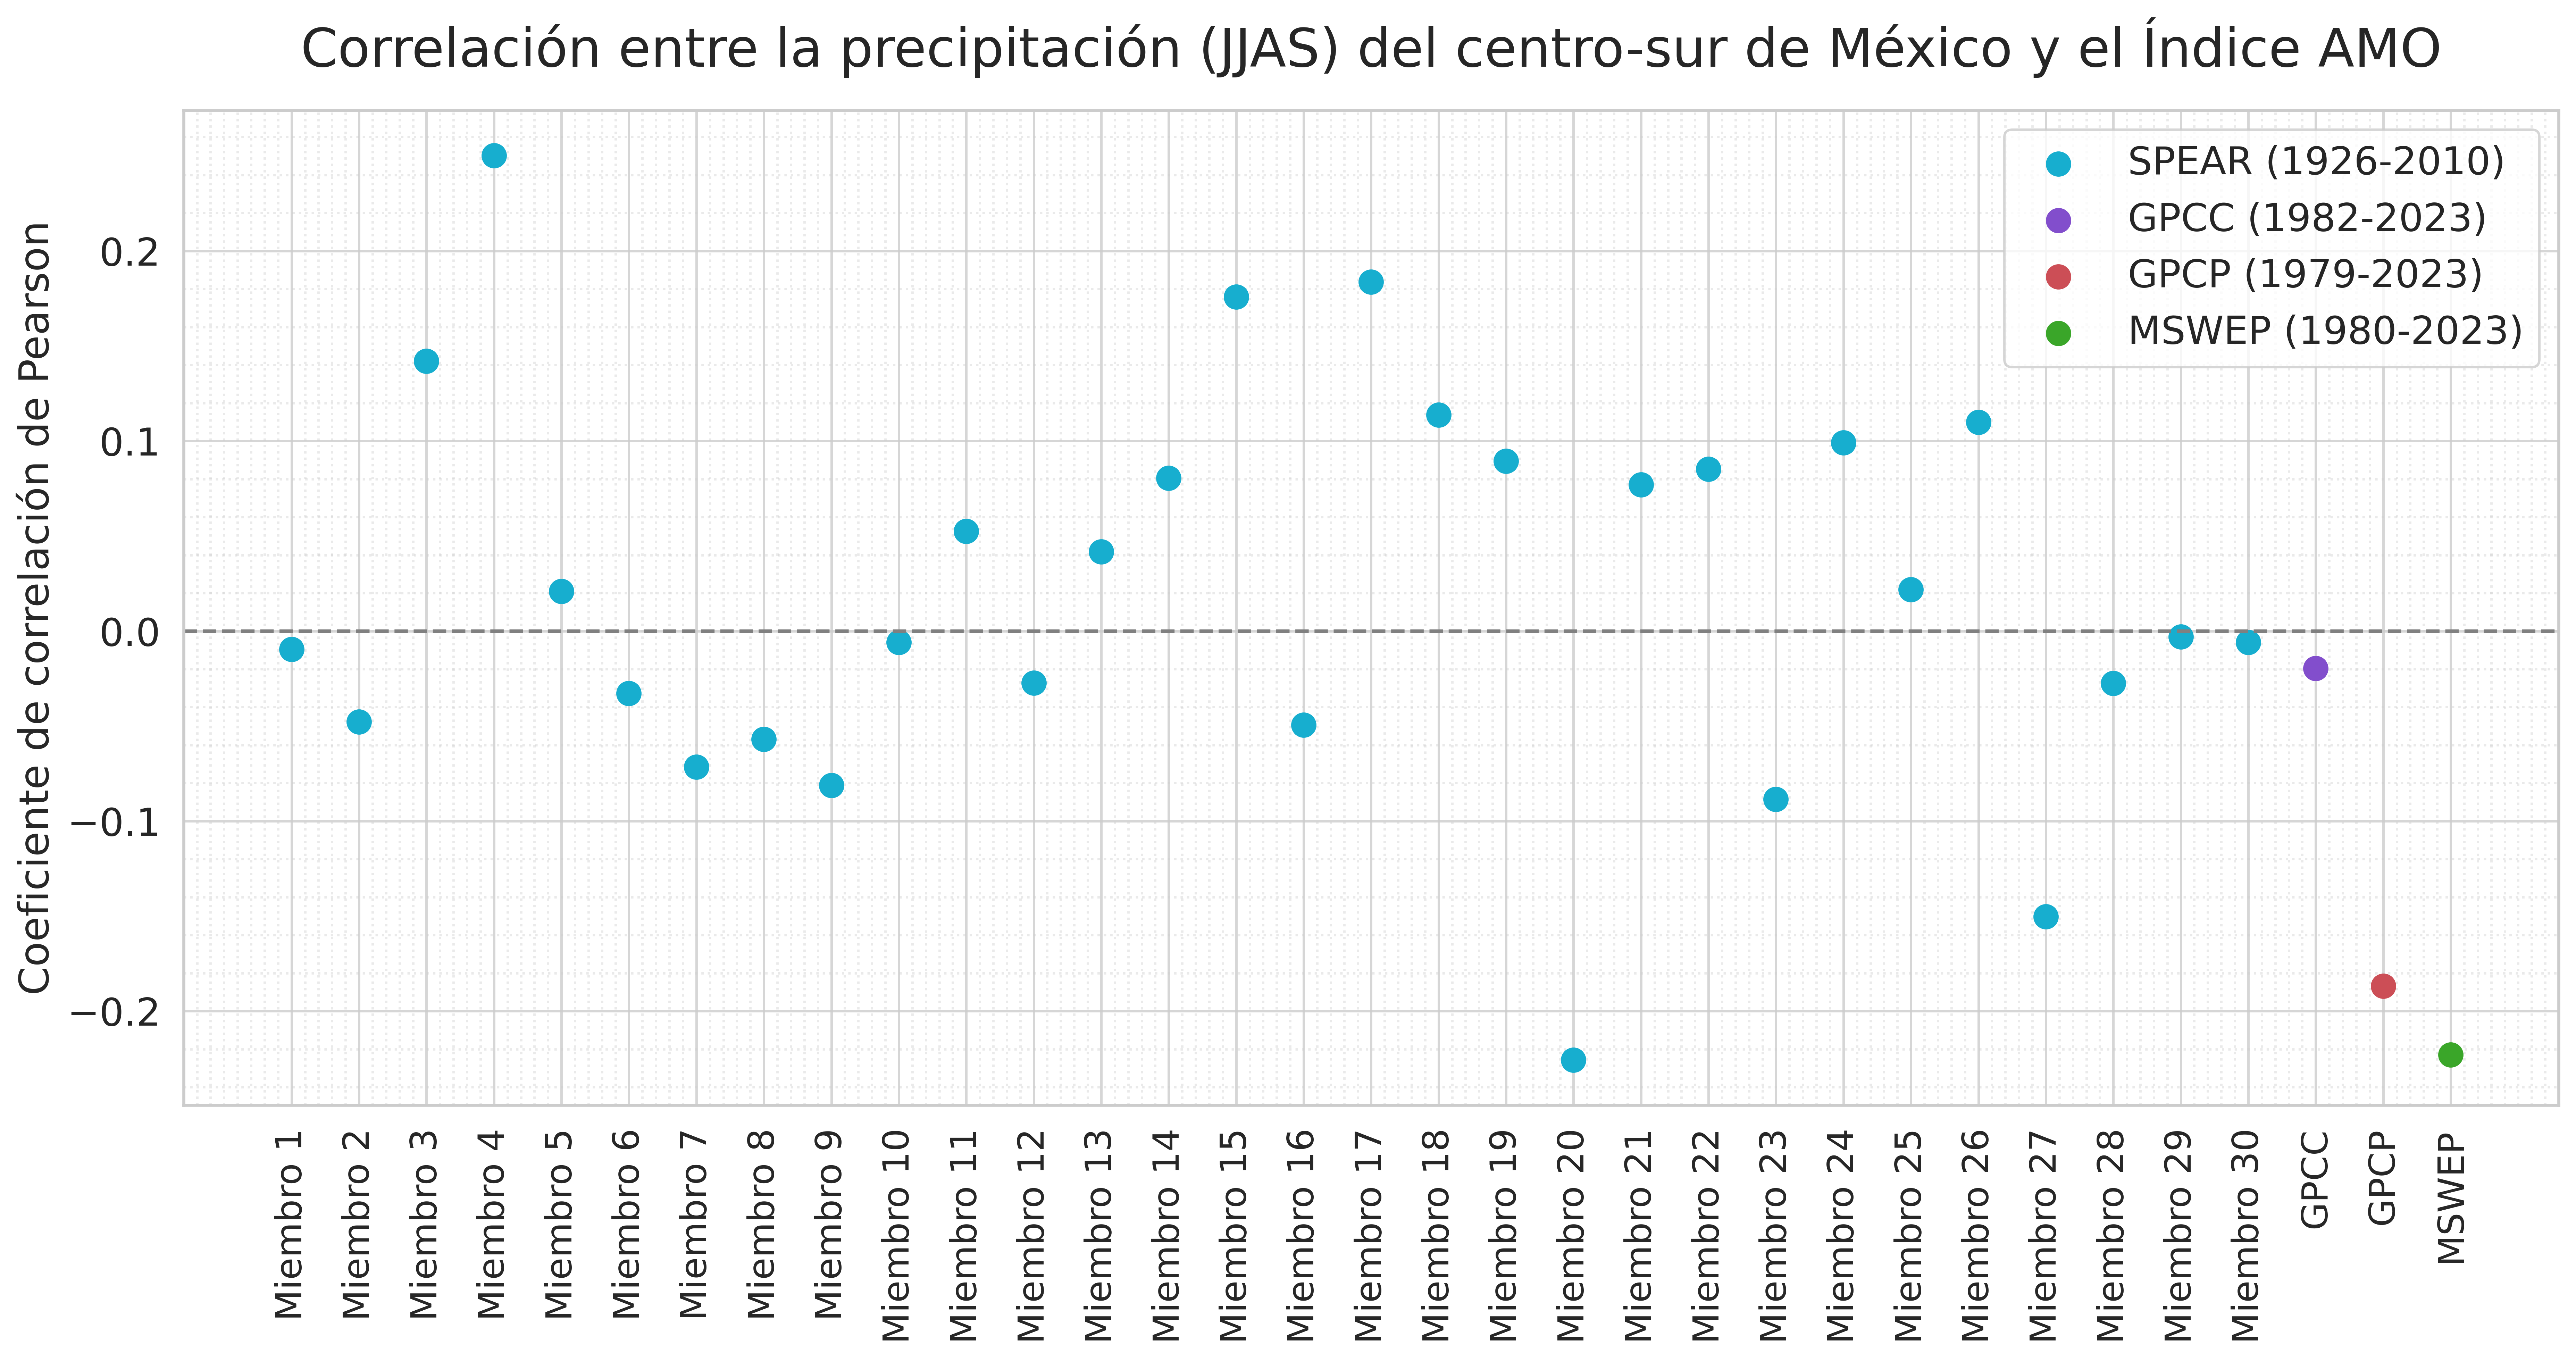

In [37]:
#hacemos la grafica con la distribucion de todos los coefs.
sns.set(style="whitegrid")
plt.figure(figsize=(15, 8), dpi=500)

plt.scatter(np.arange(0,30), correlaciones, color='#17AECF', s=90, label="SPEAR (1926-2010)")
plt.scatter([30], correlacion_gpcc, color='#824ECC', s=90, label='GPCC (1982-2023)')
plt.scatter([31], correlacion_gpcp, color='#CC4E56', s=90, label='GPCP (1979-2023)')
plt.scatter([32], correlacion_mswep, color='#3AA629', s=90, label='MSWEP (1980-2023)')

x_labels = [f"Miembro {i}" for i in range(1, 31)] + ['GPCC', 'GPCP', 'MSWEP']
x_positions = list(range(0, 33))
plt.xticks(ticks=x_positions, labels=x_labels, rotation=90, fontsize=15)
plt.grid(True, which='major', linestyle='-', alpha=0.8)  
plt.minorticks_on()
plt.grid(True, which='minor', linestyle=':', alpha=0.4)  
plt.yticks(fontsize=16)
plt.axhline(0, color='grey', linestyle='--', linewidth=1.5)
plt.ylabel(r"Coeficiente de correlación de Pearson", fontsize=17)
plt.title("Correlación entre la precipitación (JJAS) del centro-sur de México y el Índice AMO", fontsize=22, pad=18, x=0.5)
plt.legend(fontsize=16, loc='upper right')
plt.tight_layout()
plt.show()

In [38]:
gpcp_tendencia_sinamv=np.load('predicciones_GPCP_AMV.npy')
gpcc_tendencia_sinamv=np.load('predicciones_GPCC_AMV.npy')
mswep_tendencia_sinamv=np.load('predicciones_MSWEP_AMV.npy')

gpcp_residual=np.load('residual_GPCP_AMV.npy')
gpcc_residual=np.load('residual_GPCC_AMV.npy')
mswep_residual=np.load('residual_MSWEP_AMV.npy')

In [39]:
sns.set(style="whitegrid")
X_años = [np.arange(1982, 2024),np.arange(1979, 2024),np.arange(1980, 2024)]


fig, axes = plt.subplots(3, 1, figsize=(13, 16), dpi=500)
axes = axes.flatten()

paneles = ['a)', 'b)', 'c)', 'd)']
pendientes = [gpcc_tendencia_sinamv,gpcp_tendencia_sinamv,mswep_tendencia_sinamv]
datos = [gpcc_residual,gpcp_residual,mswep_residual]
pvalues=[0.80796,0.85457, 0.8047]
beta1=[-0.26,-0.18,-0.3]
titulos=["GPCC (1982-2023)","GPCP (1979-2023)","MSWEP (1980-2023)"]


for i, ax in enumerate(axes):
    ax.plot(X_años[i], datos[i], color='#186890', label='Serie de tiempo', linewidth=2)
    ax.plot(X_años[i], pendientes[i], color='#bd1536', label='Línea de regresión', linewidth=2.5)
    ax.text(0.04, 0.95, paneles[i], transform=ax.transAxes,fontsize=26, fontname='Liberation Serif', fontweight='bold',va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.27', linewidth=1))
    
    ax.text(0.45, 0.95, rf'$\beta_1$ = {beta1[i]} mm día$^{{-1}}$ siglo$^{{-1}}$',transform=ax.transAxes, fontsize=22,fontname='Liberation Serif', fontweight='normal',
            va='top', ha='right',bbox=dict(facecolor='#E3E3E3', edgecolor='white', boxstyle='round,pad=0.27', linewidth=1))
    
    ax.text(0.63, 0.945, rf'P-value = {pvalues[i]:.2f}',transform=ax.transAxes,fontsize=22,fontname='Liberation Serif',fontweight='normal',
    va='top', ha='right',bbox=dict(facecolor='white', edgecolor='gray',boxstyle='round,pad=0.3',alpha=0.8,linewidth=1.2))

    if i==0:
        ax.legend(fancybox=True,shadow=True,loc="upper right",fontsize=16)

    #eje x (años por dataset)
    ax.set_xlim(X_años[i][0], X_años[i][-1])
    ax.set_xlabel('Año',fontsize=21)
    ax.set_ylabel('Residual [mm día$^{-1}$]', fontsize=21)
    ax.set_title(titulos[i], fontsize=24, pad=13)
    ax.grid(linestyle='--',alpha=0.66)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
    ax.minorticks_on()
    ax.tick_params(axis='both', labelsize=21)  
    
    #fig.subplots_adjust(hspace=0.45, wspace=0.5, bottom=0.12, top=0.92)    
    fig.suptitle('Tendencias de la precipitación (JJAS) en el centro-sur de México sin la señal de la AMO', fontsize=25, y=1)
    #eje y cada 0.5
    
plt.tight_layout()
plt.show()

In [40]:
promediosAMV_gpcc=np.load('promediosAMV_GPCC_modelo.npy')
promediosAMV_gpcp=np.load('promediosAMV_GPCP_modelo.npy')
promediosAMV_mswep=np.load('promediosAMV_MSWEP_modelo.npy')

promediosprecip_gpcc=np.load('promediosprecip_GPCC_modelo.npy')
promediosprecip_gpcp=np.load('promediosprecip_GPCP_modelo.npy')
promediosprecip_mswep=np.load('promediosprecip_MSWEP_modelo.npy')

predicciones_gpcc=np.load('predicciones_GPCC_modelo.npy')
predicciones_gpcp=np.load('predicciones_GPCP_modelo.npy')
predicciones_mswep=np.load('predicciones_MSWEP_modelo.npy')
print(len(predicciones_mswep))
print(len(promediosprecip_mswep))
print(len(promediosAMV_mswep))

44
44
44


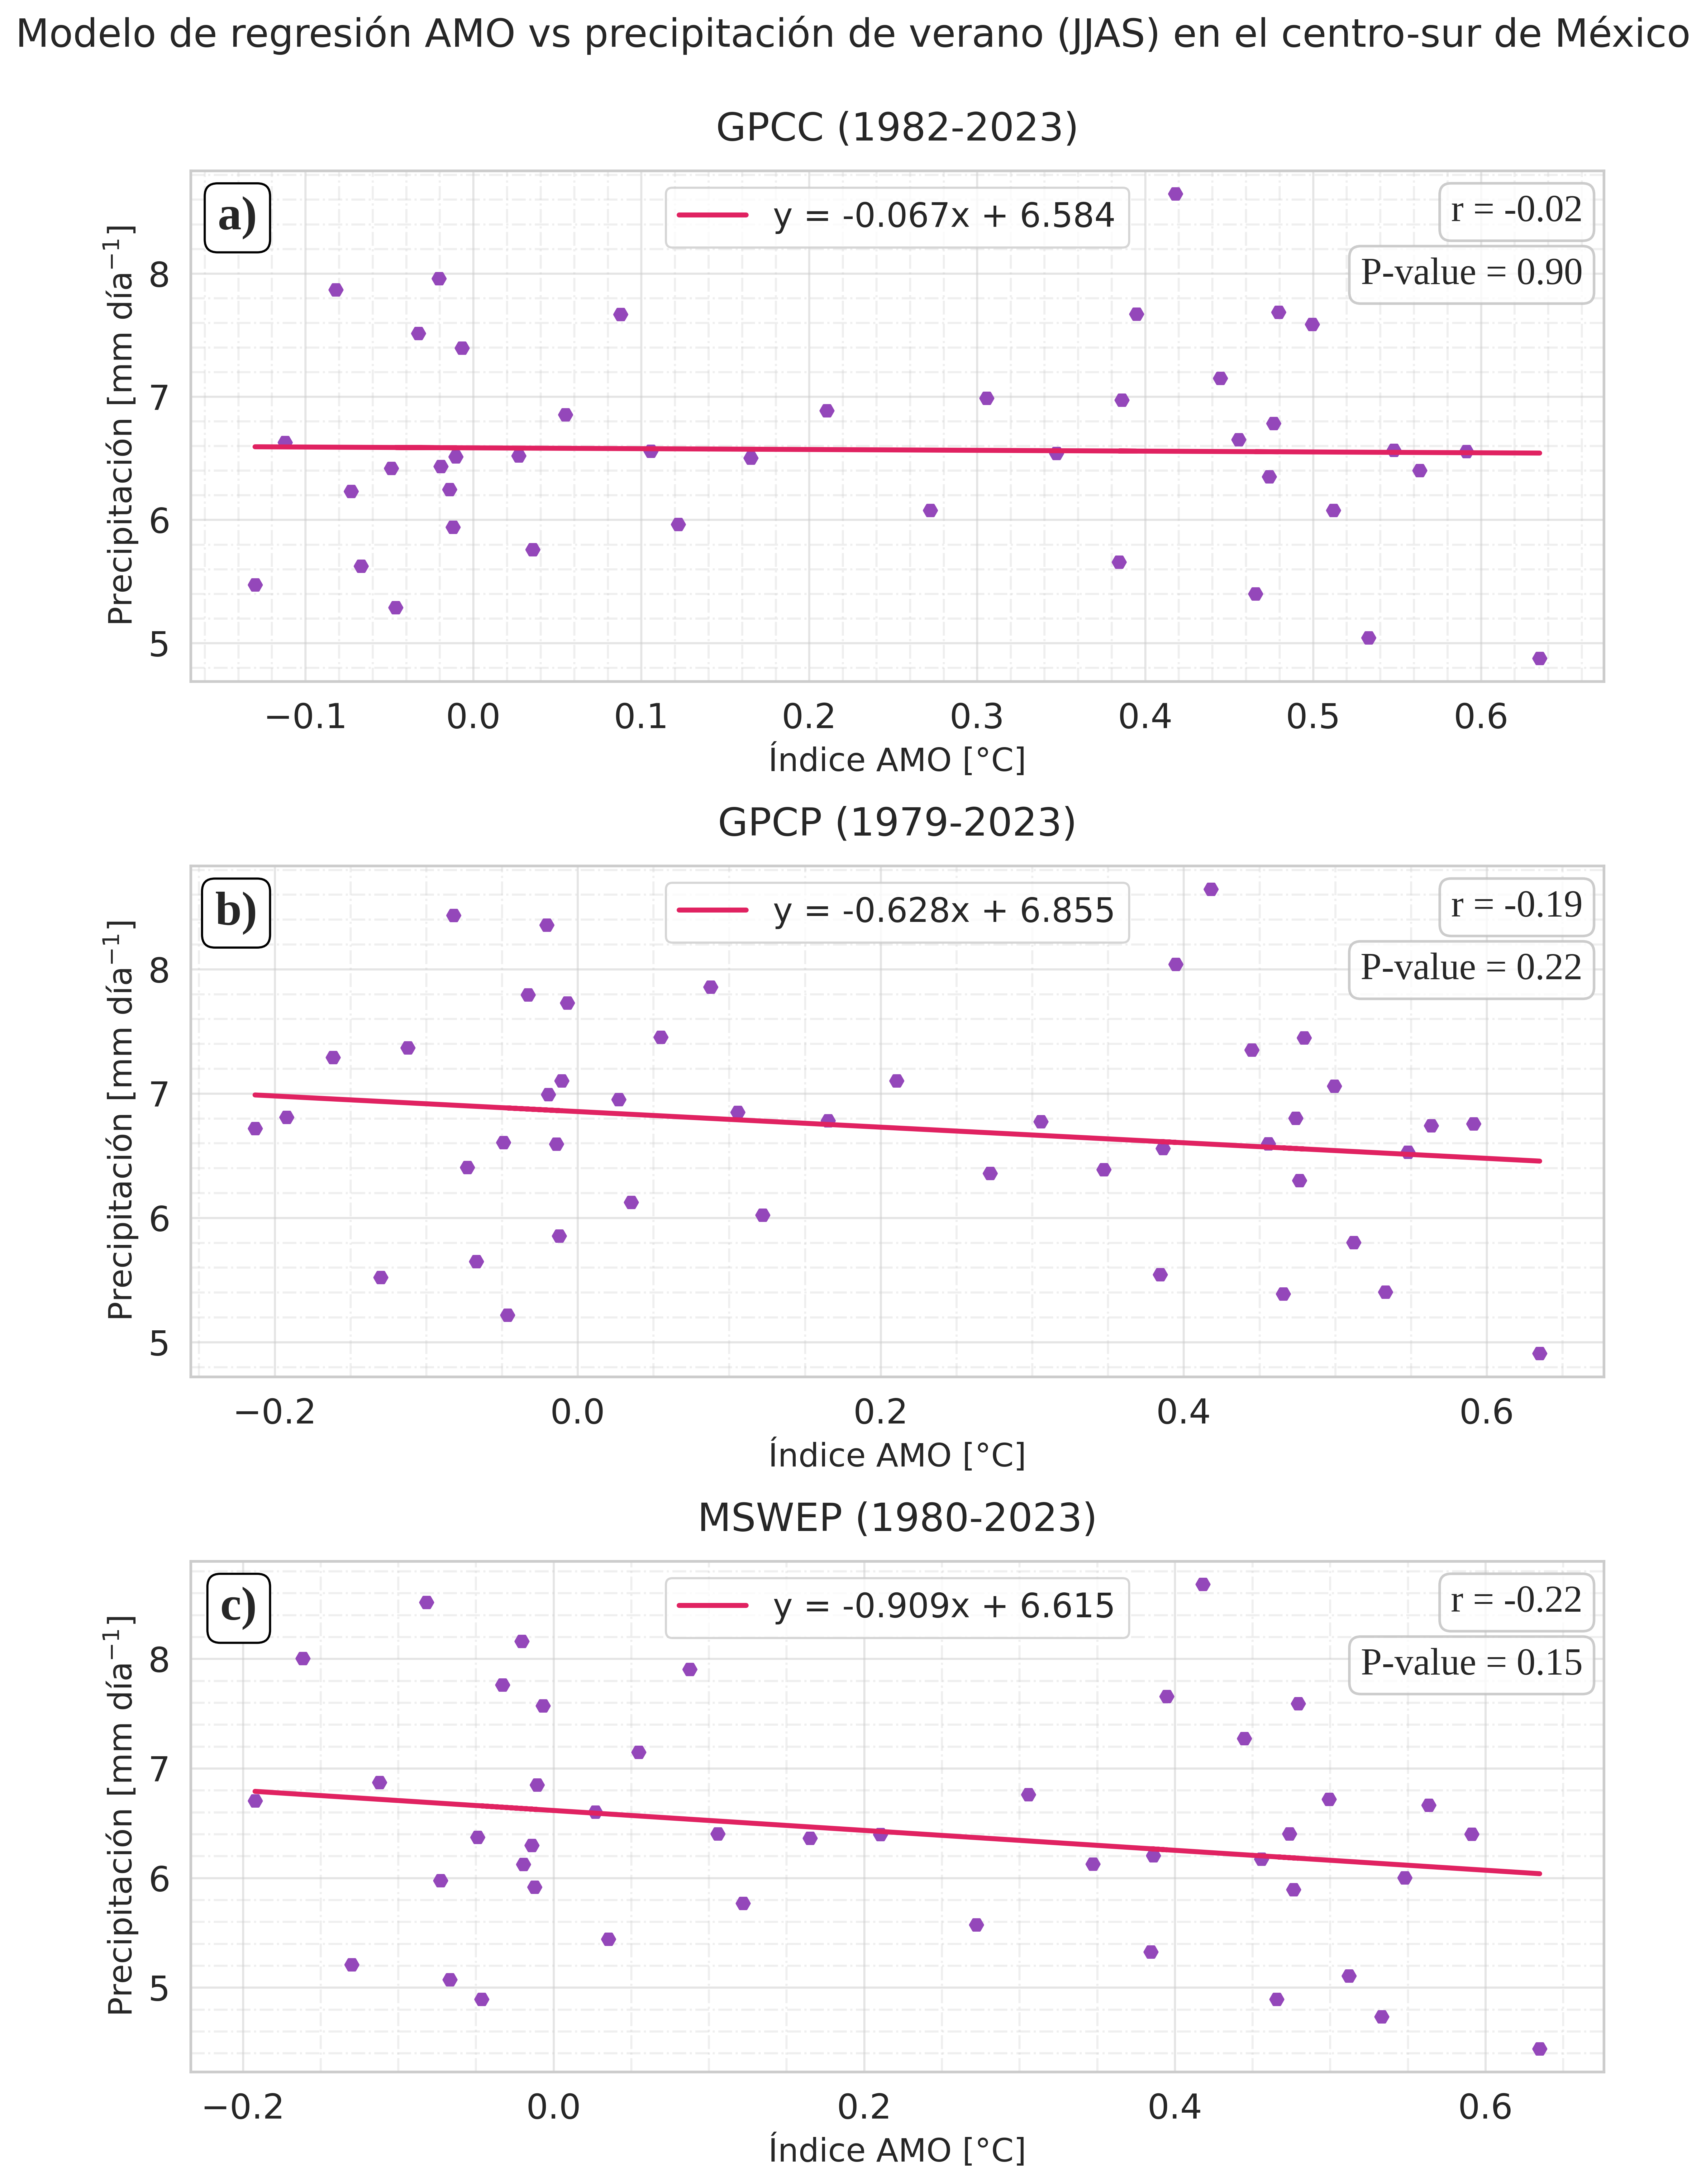

In [41]:
sns.set(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(10, 14), dpi=500)
axes = axes.flatten()

X2=[promediosAMV_gpcc, promediosAMV_gpcp, promediosAMV_mswep ]
y=[promediosprecip_gpcc, promediosprecip_gpcp, promediosprecip_mswep]
predicciones2=[predicciones_gpcc, predicciones_gpcp, predicciones_mswep]
m2_datos=[-0.0666,-0.627532,-0.90856]
b2_datos=[6.5841,6.8546,6.6153]
pval=[0.901578,0.219405,0.145626]
r=[-0.02,-0.19,-0.22]

paneles = ['a)', 'b)', 'c)']
titulos=["GPCC (1982-2023)","GPCP (1979-2023)","MSWEP (1980-2023)"]

for i, ax in enumerate(axes):
    ax.scatter(X2[i], y[i], color='#9447BA', marker="H")
    ax.plot(X2[i], predicciones2[i], color='#E02261', linewidth=2.3, label=f'y = {m2_datos[i]:.3f}x + {b2_datos[i]:.3f}')
    ax.text(0.985, 0.83, rf'P-value = {pval[i]:.2f}',transform=ax.transAxes,fontsize=17.5,fontname='Liberation Serif',fontweight='normal',
    va='top', ha='right',bbox=dict(facecolor='white', edgecolor='silver',boxstyle='round,pad=0.3',alpha=0.8,linewidth=1.2))
    ax.text(0.985,  0.953, rf'r = {r[i]:.2f}',transform=ax.transAxes,fontsize=17.5,fontname='Liberation Serif',fontweight='normal',
    va='top', ha='right',bbox=dict(facecolor='white', edgecolor='silver',boxstyle='round,pad=0.3',alpha=0.8,linewidth=1.2))
    ax.text(0.047, 0.95, paneles[i], transform=ax.transAxes,fontsize=22, fontname='Liberation Serif', fontweight='bold',va='top', ha='right',
            bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.27', linewidth=1))
    ax.set_xlabel('Índice AMO [°C]', fontsize=15)
    ax.set_ylabel('Precipitación [mm día$^{-1}$]', fontsize=15)
    ax.set_title(titulos[i],fontsize=18, pad=14)
    fig.suptitle('Modelo de regresión AMO vs precipitación de verano (JJAS) en el centro-sur de México',fontsize=18, y=1)
    ax.grid(True, which='major', linestyle='-', alpha=0.5)  
    ax.minorticks_on()
    ax.grid(True, which='minor', linestyle='-.', alpha=0.3)  
    ax.tick_params(axis='both', labelsize=16) 
    ax.grid(True)
    ax.legend(fontsize=15.5, loc="upper center")
plt.tight_layout()
plt.show()